# Avaliação Final do Pipeline e Explicabilidade

## Objetivo deste notebook

Consolidar a avaliação do pipeline two-stage completo (Stage 1 + Stage 2
+ threshold de negócio) no conjunto de teste, e aplicar SHAP para explicar
o comportamento do modelo em nível global (quais features mais importam
no geral) e individual (por que uma transação específica foi classificada
como fraude ou não). Este notebook consolida os resultados.

## Contexto herdado dos notebooks anteriores

| Etapa | Resultado |
|---|---|
| Stage 1 (Isolation Forest, corte 28%) | Recall preservado: 95,95% (teste) |
| Stage 2 (LightGBM otimizado) | PR-AUC: 0,8340 no threshold 0,5 |
| Threshold de negócio (notebook 05) | 0,18 — recall de 83,1%, 71,3% do valor de fraude recuperado |

## O que será feito

**1. Avaliação do pipeline completo, ponta a ponta**

Diferente dos notebooks 03 e 04 (que avaliaram cada stage isoladamente),
aqui calculamos o recall e as métricas **em relação ao dataset de teste
original** (antes do filtro do Stage 1) isso expõe o recall real do
sistema completo, que é necessariamente menor que o recall isolado do
Stage 2, já que fraudes descartadas no Stage 1 nunca chegam ao Stage 2.

**2. Matriz de confusão final e métricas consolidadas**

Usando o threshold de 0,18 definido no notebook 05, geramos a matriz de
confusão final do pipeline completo, com todas as métricas do escopo do
projeto.

**3. SHAP — explicabilidade global**

Cálculo dos SHAP values sobre o modelo LightGBM final, com summary plot
mostrando quais features mais contribuem para as decisões do modelo em
geral comparando com o ranking de effect size da EDA (notebook 01)
para validar consistência.

**4. SHAP — explicabilidade individual**

Waterfall plots de casos específicos: pelo menos um falso positivo e um
falso negativo "interessantes", explicando por que o modelo errou nesses
casos específicos.

**5. Consolidação dos resultados do projeto**

Tabela-resumo final unindo métricas técnicas (PR-AUC, Recall) e métricas
de negócio (valor recuperado, custo total), pronta para virar a seção de
resultados do README.

In [1]:
# ================================================================
# Avaliação do Pipeline Completo (Ponta a Ponta)
# ================================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_recall_curve, auc, recall_score,
                              precision_score, f1_score, confusion_matrix,
                              roc_auc_score, accuracy_score)

sns.set_theme(style="whitegrid", palette="muted")

# ----------------------------------------------------------------
# Carregamento de todos os artefatos necessários
# ----------------------------------------------------------------
caminho_base    = "/content/drive/MyDrive/fraud-detection-two-stage"
caminho_dados   = f"{caminho_base}/data/processed"
caminho_modelos = f"{caminho_base}/models"

# Conjunto de teste ORIGINAL (antes do filtro do Stage 1)
df_teste_completo = pd.read_parquet(f"{caminho_dados}/test_processed.parquet")

# Modelos treinados
iso_forest = joblib.load(f"{caminho_modelos}/isolation_forest_stage1.pkl")
modelo_lgbm = joblib.load(f"{caminho_modelos}/lightgbm_stage2.pkl")

# Threshold de negócio definido no notebook 05
import json
with open(f"{caminho_modelos}/cost_benefit_metadata.json") as f:
    metadados_custo = json.load(f)
THRESHOLD_NEGOCIO = metadados_custo["threshold_otimo"]

print(f"Teste completo (original): {df_teste_completo.shape[0]:,} transações | "
      f"{df_teste_completo['Class'].sum()} fraudes")
print(f"Threshold de negócio (notebook 05): {THRESHOLD_NEGOCIO}")

Teste completo (original): 56,744 transações | 74 fraudes
Threshold de negócio (notebook 05): 0.18


In [2]:
# ----------------------------------------------------------------
# APLICAÇÃO DO PIPELINE COMPLETO — Stage 1 -> Stage 2 -> Threshold
# ----------------------------------------------------------------
# Reproduz exatamente o que aconteceria em produção: toda transação
# passa pelo Stage 1; só as mais suspeitas (top 28%) seguem ao Stage 2;
# as demais são automaticamente aprovadas (nunca chegam a ser
# avaliadas pelo LightGBM).

features_modelo = [col for col in df_teste_completo.columns
                    if col not in ["Class", "transaction_id"]]

# 1. Score de anomalia do Stage 1 para TODAS as transações
scores_anomalia = -iso_forest.score_samples(df_teste_completo[features_modelo])

# 2. Aplica o mesmo corte de 28% definido no notebook 03
CORTE_STAGE1_PCT = 28
n_total = len(df_teste_completo)
n_reter = int(n_total * CORTE_STAGE1_PCT / 100)

indices_avancam_stage2 = np.argsort(scores_anomalia)[-n_reter:]
mascara_avanca_stage2 = np.zeros(n_total, dtype=bool)
mascara_avanca_stage2[indices_avancam_stage2] = True

df_teste_completo["passou_stage1"] = mascara_avanca_stage2

print(f"Transações que avançam ao Stage 2: {mascara_avanca_stage2.sum():,} "
      f"({mascara_avanca_stage2.sum()/n_total*100:.1f}%)")
print(f"Fraudes reais que avançam ao Stage 2: "
      f"{df_teste_completo.loc[mascara_avanca_stage2, 'Class'].sum()} de "
      f"{df_teste_completo['Class'].sum()}")

# 3. Para quem avança, aplica o LightGBM + threshold de negócio
df_teste_completo["y_score_final"] = 0.0  # default: quem não avança tem score 0 (aprovado)

X_avancam = df_teste_completo.loc[mascara_avanca_stage2, features_modelo]
scores_lgbm = modelo_lgbm.predict_proba(X_avancam)[:, 1]

df_teste_completo.loc[mascara_avanca_stage2, "y_score_final"] = scores_lgbm

# 4. Decisão final — aplica threshold de negócio
df_teste_completo["y_pred_final"] = (
    df_teste_completo["y_score_final"] >= THRESHOLD_NEGOCIO
).astype(int)

print(f"\nPipeline completo aplicado. Predições finais geradas.")

Transações que avançam ao Stage 2: 15,888 (28.0%)
Fraudes reais que avançam ao Stage 2: 71 de 74

Pipeline completo aplicado. Predições finais geradas.


In [3]:
# ----------------------------------------------------------------
# MÉTRICAS DO PIPELINE COMPLETO — ponta a ponta
# ----------------------------------------------------------------
# IMPORTANTE: aqui medimos contra o dataset de teste ORIGINAL,
# não o filtrado — isso expõe o recall real do sistema, já
# descontando as fraudes perdidas ainda no Stage 1.

y_true_completo = df_teste_completo["Class"]
y_pred_completo = df_teste_completo["y_pred_final"]
y_score_completo = df_teste_completo["y_score_final"]

precision, recall_curve, _ = precision_recall_curve(y_true_completo, y_score_completo)
pr_auc_pipeline = auc(recall_curve, precision)

recall_pipeline = recall_score(y_true_completo, y_pred_completo)
precision_pipeline = precision_score(y_true_completo, y_pred_completo)
f1_pipeline = f1_score(y_true_completo, y_pred_completo)
roc_auc_pipeline = roc_auc_score(y_true_completo, y_score_completo)
accuracy_pipeline = accuracy_score(y_true_completo, y_pred_completo)

tn, fp, fn, tp = confusion_matrix(y_true_completo, y_pred_completo).ravel()
fpr_pipeline = fp / (fp + tn)

print("=" * 55)
print("MÉTRICAS DO PIPELINE COMPLETO (Stage 1 + Stage 2 + Threshold)")
print("=" * 55)
print(f"\n--- Principais ---")
print(f"PR-AUC   : {pr_auc_pipeline:.4f}")
print(f"Recall   : {recall_pipeline:.4f}")

print(f"\n--- Secundárias ---")
print(f"Precision: {precision_pipeline:.4f}")
print(f"F1-Score : {f1_pipeline:.4f}")
print(f"FPR      : {fpr_pipeline:.6f}")
print(f"\nMatriz de Confusão:")
print(f"  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")

print(f"\n--- Contraste Pedagógico ---")
print(f"ROC-AUC  : {roc_auc_pipeline:.4f}")
print(f"Accuracy : {accuracy_pipeline:.4f}")

MÉTRICAS DO PIPELINE COMPLETO (Stage 1 + Stage 2 + Threshold)

--- Principais ---
PR-AUC   : 0.8003
Recall   : 0.7973

--- Secundárias ---
Precision: 0.7024
F1-Score : 0.7468
FPR      : 0.000441

Matriz de Confusão:
  TP=59  FP=25
  FN=15  TN=56645

--- Contraste Pedagógico ---
ROC-AUC  : 0.9697
Accuracy : 0.9993


## Análise — Avaliação do Pipeline Completo (Ponta a Ponta)

Diferente das avaliações isoladas dos notebooks anteriores (Stage 1 e
Stage 2 separadamente), aqui medimos a performance do **sistema completo**
— Stage 1 (Isolation Forest, corte 28%) seguido do Stage 2 (LightGBM,
threshold de negócio 0,18) contra o conjunto de teste **original**,
antes de qualquer filtragem.

**Resultado do pipeline completo:**

| Métrica | Valor |
|---|---|
| PR-AUC | 0,8003 |
| Recall | **79,73%** |
| Precision | 70,24% |
| F1-Score | 0,7468 |
| FPR | 0,044% |
| Matriz de Confusão | TP=59, FP=25, FN=15, TN=56.645 |
| ROC-AUC (contraste pedagógico) | 0,9697 |
| Accuracy (contraste pedagógico) | 99,93% |

**Por que o recall final (79,73%) é menor que os recalls parciais vistos
antes:** o pipeline é sequencial, e cada etapa perde uma fração das
fraudes reais. O Stage 1 preserva 95,95% das fraudes (71 de 74); dessas,
o Stage 2 com threshold 0,18 detecta 83,1% (59 de 71). O resultado
composto é 59 de 74 fraudes totais **79,73%**, o número real e honesto
que representa a performance do sistema em produção. Reportar apenas o
recall isolado de uma das etapas (95,95% ou 83,1%) superestimaria a
capacidade real do pipeline, já que esconde a perda acumulada entre as
etapas.

**Contraste pedagógico confirmado com dados reais do projeto:** Accuracy
(99,93%) e ROC-AUC (0,9697) parecem indicar um sistema quase perfeito,
mas o Recall revela que **15 das 74 fraudes reais (20,3%) ainda passam
despercebidas** pelo pipeline completo. Essa discrepância é exatamente a
armadilha do desbalanceamento discutida desde o objetivo inicial do
projeto, métricas convencionais mascaram falhas reais de detecção em
cenários de classes extremamente desbalanceadas.

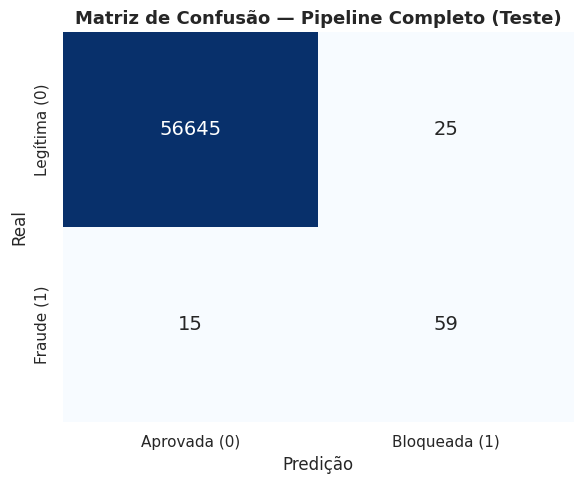

In [4]:
# ----------------------------------------------------------------
# Matriz de Confusão do Pipeline Completo
# ----------------------------------------------------------------

matriz_confusao = confusion_matrix(y_true_completo, y_pred_completo)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matriz_confusao, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Aprovada (0)", "Bloqueada (1)"],
            yticklabels=["Legítima (0)", "Fraude (1)"],
            ax=ax, cbar=False, annot_kws={"fontsize": 14})
ax.set_xlabel("Predição")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — Pipeline Completo (Teste)",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
# ----------------------------------------------------------------
# DEMONSTRAÇÃO DA ARMADILHA — Accuracy de "aprovar tudo" vs. pipeline real
# ----------------------------------------------------------------
# Evidencia, com os dados reais deste projeto, por que Accuracy não
# deve guiar nenhuma decisão aqui é reportada apenas como
# contraste pedagógico, nunca como critério de escolha de modelo
# ou threshold.

y_pred_aprova_tudo = np.zeros(len(y_true_completo))  # nunca bloqueia nada

accuracy_aprova_tudo = accuracy_score(y_true_completo, y_pred_aprova_tudo)
recall_aprova_tudo = recall_score(y_true_completo, y_pred_aprova_tudo, zero_division=0)

print("=" * 55)
print("DEMONSTRAÇÃO — 'Aprovar Tudo' vs. Pipeline Real")
print("=" * 55)

print(f"\n'Aprovar tudo' (nenhuma fraude detectada, nenhum esforço):")
print(f"  Accuracy: {accuracy_aprova_tudo:.4f}  |  Recall: {recall_aprova_tudo:.4f}")

print(f"\nPipeline completo (Stage 1 + Stage 2 + threshold {THRESHOLD_NEGOCIO}):")
print(f"  Accuracy: {accuracy_pipeline:.4f}  |  Recall: {recall_pipeline:.4f}")

diferenca_accuracy = abs(accuracy_aprova_tudo - accuracy_pipeline)
print(f"\nDiferença de Accuracy entre os dois cenários: {diferenca_accuracy:.4f} "
      f"({diferenca_accuracy*100:.2f} pontos percentuais)")

print("\nConclusão: a Accuracy é praticamente idêntica entre 'não fazer nada' "
      "\ne um pipeline sofisticado de duas etapas enquanto o Recall expõe a "
      "\ndiferença real entre os dois cenários. Por isso, Accuracy é reportada "
      "\nneste projeto apenas como contraste pedagógico, nunca como métrica "
      "\nde decisão.")

DEMONSTRAÇÃO — 'Aprovar Tudo' vs. Pipeline Real

'Aprovar tudo' (nenhuma fraude detectada, nenhum esforço):
  Accuracy: 0.9987  |  Recall: 0.0000

Pipeline completo (Stage 1 + Stage 2 + threshold 0.18):
  Accuracy: 0.9993  |  Recall: 0.7973

Diferença de Accuracy entre os dois cenários: 0.0006 (0.06 pontos percentuais)

Conclusão: a Accuracy é praticamente idêntica entre 'não fazer nada' 
e um pipeline sofisticado de duas etapas enquanto o Recall expõe a 
diferença real entre os dois cenários. Por isso, Accuracy é reportada 
neste projeto apenas como contraste pedagógico, nunca como métrica 
de decisão.


## Análise — A Armadilha do Desbalanceamento, Demonstrada com Dados Reais

Para tornar tangível a limitação da Accuracy discutida desde o objetivo
inicial do projeto, comparamos o cenário de "aprovar todas as transações
sem nenhum modelo" contra o pipeline completo desenvolvido:

| Cenário | Accuracy | Recall |
|---|---|---|
| Aprovar tudo (nenhum esforço) | 99,87% | 0,00% |
| Pipeline completo (Stage 1 + 2 + threshold) | 99,93% | 79,73% |

**A diferença de Accuracy entre os dois cenários é de apenas 0,06 pontos
percentuais** apesar de um deles não detectar absolutamente nenhuma
fraude, e o outro identificar quase 80% de todas as fraudes reais do
conjunto de teste.

Essa demonstração evidencia, com dados do próprio projeto, por que
Accuracy nunca deveria ser usada como métrica de decisão em problemas de
classes extremamente desbalanceadas: ela é dominada pela classe
majoritária (transações legítimas, 99,8% dos casos) a ponto de se tornar
praticamente insensível ao desempenho na classe de interesse (fraude).
Um sistema que não faz absolutamente nada e um sistema sofisticado de
duas etapas, com otimização de hiperparâmetros e análise de custo de
negócio, obtêm Accuracy virtualmente idêntica mas resultados de negócio
radicalmente diferentes.

**Conclusão:** esta demonstração confirma, com evidência empírica gerada
pelo próprio pipeline, a premissa que motivou todas as escolhas
metodológicas do projeto (split temporal, métricas PR-AUC/Recall como
guia de decisão, threshold por custo de negócio). Accuracy e ROC-AUC são
mantidas neste projeto exclusivamente como contraste pedagógico mas nunca
como critério de escolha de modelo, threshold ou arquitetura.

In [6]:
# ================================================================
# SHAP — Explicabilidade Global e Individual
# ================================================================

import shap

# ----------------------------------------------------------------
# Inicialização do explainer — TreeExplainer é o mais eficiente
# para modelos baseados em árvore como o LightGBM
# ----------------------------------------------------------------
# Usamos as transações que passaram pelo Stage 1 (mesmo universo
# em que o LightGBM efetivamente opera) para o cálculo do SHAP,
# já que não faz sentido explicar decisões sobre transações que
# o Stage 2 nunca avaliou.

X_shap = df_teste_completo.loc[df_teste_completo["passou_stage1"], features_modelo]

explainer = shap.TreeExplainer(modelo_lgbm)
shap_values = explainer.shap_values(X_shap)

# Em classificação binária, o LightGBM via sklearn API pode retornar
# uma lista [classe_0, classe_1] ou um array único — normalizamos aqui
if isinstance(shap_values, list):
    shap_values_fraude = shap_values[1]  # classe positiva (fraude)
else:
    shap_values_fraude = shap_values

print(f"SHAP values calculados para {X_shap.shape[0]:,} transações.")

SHAP values calculados para 15,888 transações.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


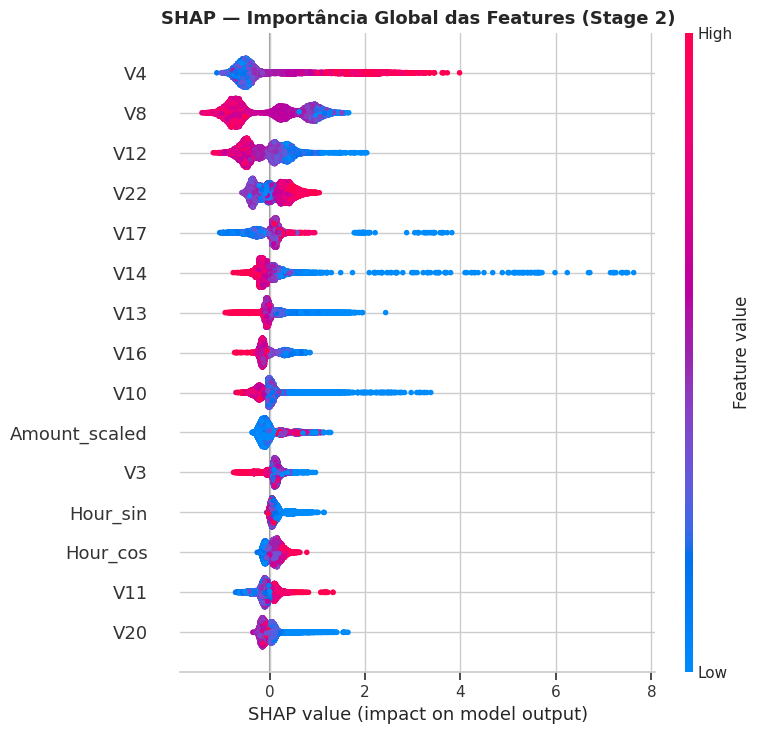

In [7]:
# ----------------------------------------------------------------
# EXPLICABILIDADE GLOBAL — Summary Plot
# ----------------------------------------------------------------
# Mostra, para o conjunto inteiro, quais features mais influenciam
# as decisões do modelo, e em que direção (valores altos/baixos
# da feature empurram a predição para fraude ou não).

shap.summary_plot(shap_values_fraude, X_shap, show=False, max_display=15)
plt.title("SHAP — Importância Global das Features (Stage 2)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Análise — SHAP: Explicabilidade Global do Stage 2

Calculamos os valores SHAP sobre as 15.888 transações que passaram pelo
filtro do Stage 1, usando `TreeExplainer` sobre o modelo LightGBM final,
para identificar quais features mais influenciam as decisões do modelo
em nível global.

**Top features por importância SHAP:** V4, V8, V12, V22, V17, V14, V13,
V16, V10 lideram o ranking, seguidas por Amount_scaled, V3, Hour_sin,
Hour_cos, V11 e V20 com impacto mais discreto.

**Comparação com o ranking de Effect Size da EDA (notebook 01):**

| Posição | Effect Size (EDA) | SHAP (Stage 2) |
|---|---|---|
| 1º | V17 | V4 |
| 2º | V14 | V8 |
| 3º | V12 | V12 |

V12 mantém posição de destaque em ambos os rankings, reforçando sua
robustez como sinal discriminativo. Já **V4 e V8, que tinham effect size
modesto na EDA, saltaram para o topo da importância SHAP** resultado
esperado e não contraditório, dado que effect size é uma métrica linear
e univariada (mede apenas diferença de médias, feature a feature,
isoladamente), enquanto SHAP captura a contribuição real de cada feature
dentro do modelo treinado, incluindo interações não-lineares entre
variáveis que a análise da EDA não conseguiria detectar. Além disso, o
SHAP foi calculado sobre o subconjunto já filtrado pelo Stage 1, cuja
distribuição difere do dataset completo analisado na EDA.

**Direção dos efeitos, consistente com a EDA:** V14 apresenta padrão em
que valores baixos (pontos azuis) empurram fortemente a predição em
direção à fraude confirmando o deslocamento para valores negativos
identificado nos boxplots do notebook 01. V4 apresenta o padrão inverso:
valores altos aumentam a probabilidade de fraude segundo o modelo.

**Observação relevante sobre as features de engenharia:** apesar do
trabalho de feature engineering (RobustScaler em Amount, encoding
cíclico de Hour), essas features apresentam impacto relativamente baixo
na decisão final do modelo, comparado às componentes PCA. Isso não
invalida essas transformações porque a EDA já havia demonstrado que Amount e
Hour carregam sinal real, apenas mais discreto que o de diversas
componentes V. É importante reportar que
o modelo aprendeu a se apoiar majoritariamente nas componentes PCA
originais para tomar suas decisões.

A análise SHAP confirma que o modelo está aprendendo
padrões consistentes com a estrutura de dados identificada na EDA (mesma
direção de efeito para features em comum), enquanto revela relações
adicionais não-lineares que a análise exploratória univariada não teria
condições de capturar validando o valor de complementar a EDA com
explicabilidade pós-modelo.

In [8]:
# ----------------------------------------------------------------
# Comparação: ranking SHAP vs. ranking de Effect Size (notebook 01)
# ----------------------------------------------------------------
# Valida se as features mais discriminativas identificadas na EDA
# (V17, V14, V12...) também lideram a importância real do modelo.

importancia_shap = pd.DataFrame({
    "feature": features_modelo,
    "shap_importance": np.abs(shap_values_fraude).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

print("Top 10 features por importância SHAP:")
print(importancia_shap.head(10).to_string(index=False))

Top 10 features por importância SHAP:
      feature  shap_importance
           V4         0.737160
           V8         0.712346
          V12         0.373078
          V22         0.290790
          V17         0.211179
          V14         0.199245
          V13         0.189391
          V16         0.186300
          V10         0.186164
Amount_scaled         0.174051


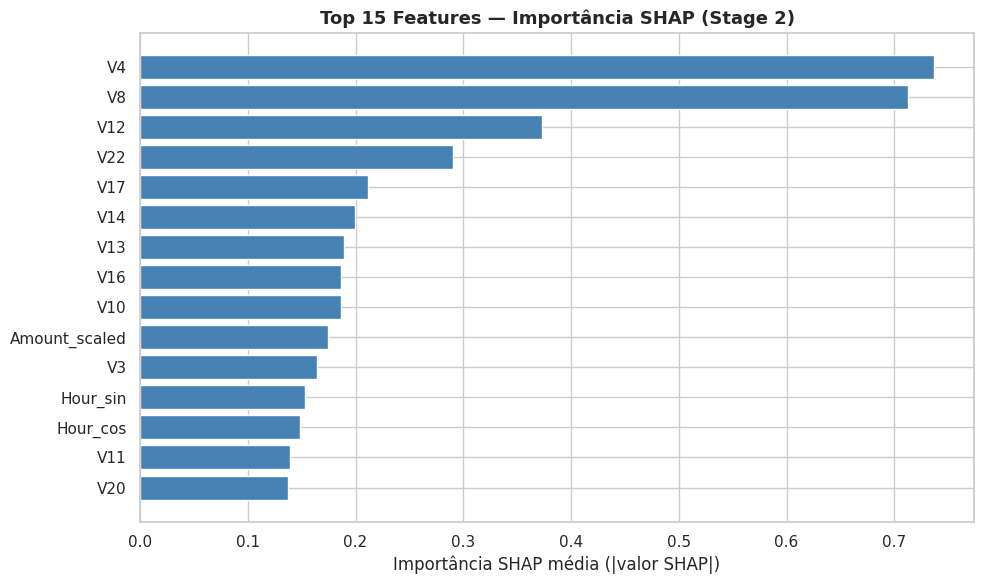

In [9]:
# ----------------------------------------------------------------
# Visualização — Bar plot de importância SHAP (mais legível que
# o summary_plot para comparação direta com o effect size da EDA)
# ----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))
top15 = importancia_shap.head(15)
ax.barh(top15["feature"][::-1], top15["shap_importance"][::-1], color="steelblue")
ax.set_xlabel("Importância SHAP média (|valor SHAP|)")
ax.set_title("Top 15 Features — Importância SHAP (Stage 2)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Análise — SHAP: Explicabilidade Global do Stage 2 (Complemento Numérico)

**Ranking exato de importância SHAP (média do valor absoluto):**

| Feature | Importância SHAP |
|---|---|
| V4 | 0,7372 |
| V8 | 0,7123 |
| V12 | 0,3731 |
| V22 | 0,2908 |
| V17 | 0,2112 |
| V14 | 0,1992 |
| V13 | 0,1894 |
| V16 | 0,1863 |
| V10 | 0,1862 |
| Amount_scaled | 0,1741 |

**Concentração de sinal em duas features:** V4 e V8 concentram uma
importância muito superior às demais juntas, somam mais que o dobro da
terceira colocada (V12). A partir da 3ª posição, a queda de importância
é gradual e suave, indicando um grupo mais amplo de features que
contribuem de forma distribuída, sem nenhuma se destacar isoladamente
como V4 e V8 fazem.

**Reforço da observação anterior:** essa concentração torna ainda mais
evidente a divergência com o ranking de Effect Size da EDA, onde V4 e V8
não apareciam entre as mais discriminativas de forma isolada (V4 em 9º
lugar, V8 fora do top 10). Isso reforça que o LightGBM está capturando,
através dessas duas variáveis, um padrão de interação ou não-linearidade
que a análise univariada da EDA não conseguiria detectar, validando a
importância de complementar a EDA com explicabilidade pós-modelo.

**Amount_scaled entra no top 10**, confirmando que o valor da transação
mantém relevância real para o modelo, ainda que distante da magnitude de
V4/V8/V12.

In [10]:
# ----------------------------------------------------------------
# Identificação de casos interessantes: 1 Falso Positivo e 1 Falso Negativo
# ----------------------------------------------------------------

df_avaliados = df_teste_completo.loc[df_teste_completo["passou_stage1"]].copy()
df_avaliados = df_avaliados.reset_index(drop=True)

# Falso Positivo — legítima classificada como fraude
mask_fp = (df_avaliados["Class"] == 0) & (df_avaliados["y_pred_final"] == 1)
# Escolhe o FP com maior score (o "mais confiante" errado — caso mais interessante)
idx_fp = df_avaliados.loc[mask_fp, "y_score_final"].idxmax()

# Falso Negativo — fraude não detectada
mask_fn = (df_avaliados["Class"] == 1) & (df_avaliados["y_pred_final"] == 0)
# Escolhe o FN com maior score entre os que ainda ficaram abaixo do threshold
# (o "quase pegou" — caso mais interessante para discussão)
idx_fn = df_avaliados.loc[mask_fn, "y_score_final"].idxmax()

print(f"Caso Falso Positivo selecionado — índice {idx_fp}")
print(f"  Score: {df_avaliados.loc[idx_fp, 'y_score_final']:.4f} | "
      f"Amount: {df_avaliados.loc[idx_fp, 'Amount_scaled']:.4f}")

print(f"\nCaso Falso Negativo selecionado — índice {idx_fn}")
print(f"  Score: {df_avaliados.loc[idx_fn, 'y_score_final']:.4f} | "
      f"Amount: {df_avaliados.loc[idx_fn, 'Amount_scaled']:.4f}")

Caso Falso Positivo selecionado — índice 12942
  Score: 0.8780 | Amount: 346.8604

Caso Falso Negativo selecionado — índice 1121
  Score: 0.0061 | Amount: -0.2093


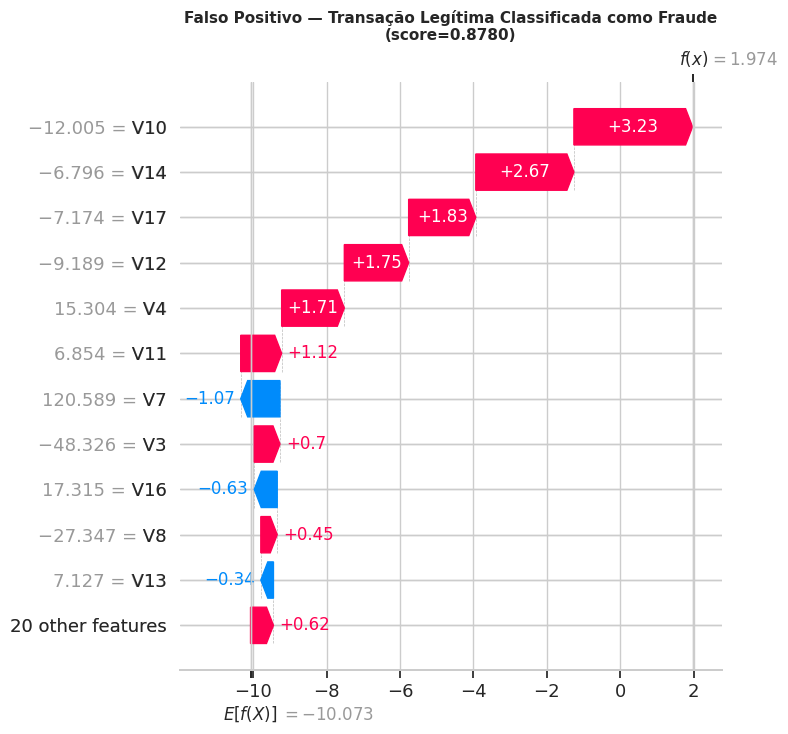

In [11]:
# ----------------------------------------------------------------
# Waterfall Plot — Falso Positivo
# ----------------------------------------------------------------
# Mostra exatamente quais features "convenceram" o modelo de que
# essa transação legítima era fraude.

explicacao_fp = shap.Explanation(
    values=shap_values_fraude[idx_fp],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray))
                else explainer.expected_value,
    data=X_shap.iloc[idx_fp],
    feature_names=features_modelo
)

shap.plots.waterfall(explicacao_fp, show=False, max_display=12)
plt.title(f"Falso Positivo — Transação Legítima Classificada como Fraude\n"
          f"(score={df_avaliados.loc[idx_fp, 'y_score_final']:.4f})",
          fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

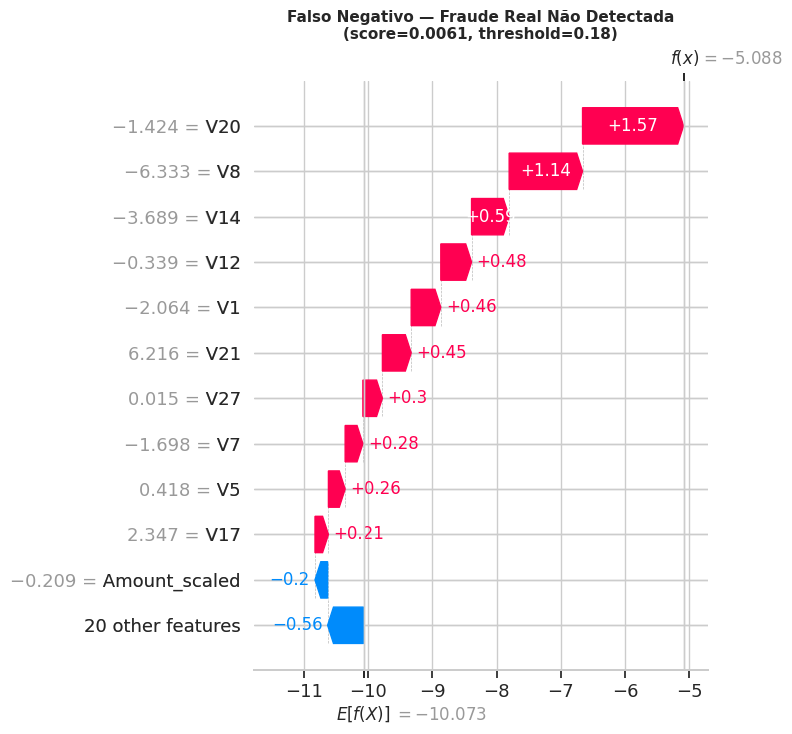

In [12]:
# ----------------------------------------------------------------
# Waterfall Plot — Falso Negativo
# ----------------------------------------------------------------
# Mostra por que o modelo não teve confiança suficiente para
# classificar essa fraude real como fraude.

explicacao_fn = shap.Explanation(
    values=shap_values_fraude[idx_fn],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray))
                else explainer.expected_value,
    data=X_shap.iloc[idx_fn],
    feature_names=features_modelo
)

shap.plots.waterfall(explicacao_fn, show=False, max_display=12)
plt.title(f"Falso Negativo — Fraude Real Não Detectada\n"
          f"(score={df_avaliados.loc[idx_fn, 'y_score_final']:.4f}, "
          f"threshold={THRESHOLD_NEGOCIO})",
          fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## Análise — SHAP: Explicabilidade Individual (Casos Específicos)

**Caso 1 — Falso Positivo (transação legítima, score=0,878, Amount=€346,86)**

O modelo classificou essa transação legítima como fraude principalmente
por causa de valores extremamente negativos em V10 (-12,01), V14 (-6,80),
V17 (-7,17) e V12 (-9,19) exatamente as features que a EDA identificou
como mais discriminativas de fraude, e na mesma direção (negativa)
observada nos boxplots do notebook 01. Este é um falso positivo
"compreensível": o modelo seguiu corretamente o padrão aprendido, mas essa
transação legítima específica apresentou, por características genuínas
e atípicas, valores nas componentes PCA que coincidem com o perfil
comportamental de fraude. Apenas V7 (120,59) contribuiu de forma relevante
para reduzir a suspeita (-1,07), mas não o suficiente para reverter a
classificação.

**Caso 2 — Falso Negativo (fraude real, score=0,0061, threshold=0,18)**

Esta fraude passou quase completamente despercebida pelo modelo com score
de apenas 0,0061, muito distante do threshold de 0,18. Diferente do caso
anterior, nenhuma das features mais associadas a fraude na EDA (V17, V14,
V12) apresentou contribuição dominante; as maiores influências vieram de
V20 (+1,57) e V8 (+1,14). Mesmo somando todas as contribuições positivas
identificadas, o valor final (f(x)=-5,088) permaneceu muito distante da
região de decisão de fraude. Isso sugere que essa transação representa um
padrão de fraude atipicamente diferente da maioria dos casos vistos no
treino que pode ser possivelmente uma tática ou perfil de fraude sub-representado no
dataset, evidenciando uma limitação real e honesta do modelo: ele tende a
reconhecer bem os padrões de fraude mais comuns, mas pode falhar diante de
variações menos frequentes.

**Valor para o projeto:** esses dois casos ilustram, de forma concreta, os
dois tipos de erro que a arquitetura two-stage produz, um falso positivo
"defensável" (o modelo segue um padrão real, mas a transação é uma exceção
legítima) e um falso negativo que expõe a fronteira de generalização do
modelo diante de fraudes com perfil atípico.

# **Conclusão**

Este notebook consolidou a avaliação do pipeline two-stage completo
(Stage 1 + Stage 2 + threshold de negócio) e aplicou SHAP para explicar
o comportamento do modelo em nível global e individual.

**1. Performance real do pipeline, ponta a ponta**
Diferente das avaliações isoladas dos notebooks anteriores, aqui medimos
o sistema completo contra o conjunto de teste original (antes de
qualquer filtragem):

| Métrica | Valor |
|---|---|
| PR-AUC | 0,8003 |
| **Recall** | **79,73%** |
| Precision | 70,24% |
| F1-Score | 0,7468 |
| Matriz de Confusão | TP=59, FP=25, FN=15, TN=56.645 |

Esse recall de 79,73% é o número real e honesto de produção, resultado
da composição sequencial de perdas entre etapas: 95,95% de recall
preservado no Stage 1, multiplicado por 83,1% de recall do Stage 2 no
threshold de negócio (0,18). Reportar apenas os recalls parciais de cada
etapa isoladamente superestimaria a capacidade real do sistema.

**2. A armadilha do desbalanceamento, demonstrada com dados do próprio projeto**

Comparamos o pipeline completo contra um cenário de "aprovar tudo" (sem
nenhum modelo): a diferença de Accuracy entre os dois foi de apenas 0,06
pontos percentuais (99,87% vs. 99,93%), enquanto o Recall revelou a
diferença real de 0% para 79,73% de fraudes detectadas. Essa
demonstração confirma, com evidência empírica, a premissa que motivou
todas as escolhas metodológicas do projeto desde o objetivo inicial:
Accuracy e ROC-AUC são mantidas apenas como contraste pedagógico, nunca
como critério de decisão.

**3. Explicabilidade global via SHAP**

V4 e V8 concentram a maior importância no modelo (0,7372 e 0,7123,
respectivamente), num patamar destacadamente superior às demais
features esse resultado diverge do ranking de effect size da EDA
(liderado por V17, V14, V12), evidenciando que o LightGBM captura
interações não-lineares entre variáveis que uma análise univariada não
consegue detectar. V12 se manteve relevante em ambas as análises,
reforçando sua robustez como sinal discriminativo. As features de
engenharia (Amount_scaled, Hour_sin, Hour_cos) mostraram impacto
relativamente modesto na decisão final, comparadas às componentes PCA
originais.

**4. Explicabilidade individual — dois casos ilustrativos**

- Um **Falso Positivo** (transação legítima com Amount de €346,86) foi
  classificado como fraude por apresentar valores extremos exatamente
  nas features mais associadas a fraude na EDA (V10, V14, V17, V12) um
  erro "defensável", em que o modelo seguiu corretamente o padrão
  aprendido diante de uma transação legítima atípica.
- Um **Falso Negativo** (fraude real com score de apenas 0,0061) revelou
  um padrão de features bem diferente do perfil típico de fraude
  identificado no treino, sugerindo uma tática ou perfil de fraude
  sub-representado no dataset podendo ser uma limitação real e honesta do modelo
  diante de variações menos frequentes de comportamento fraudulento.

## Síntese dos resultados do projeto

| Dimensão | Resultado |
|---|---|
| Recall do pipeline completo | 79,73% |
| Valor de fraude recuperado (notebook 05) | 71,3% |
| Redução de custo vs. "sem modelo" | ~60% |
| Redução de volume processado no Stage 2 | 72% (retém 28%) |
| Principal limitação identificada | Recall ainda deixa ~20% das fraudes passarem; maior custo residual vem do processo administrativo de revisão, não do erro do modelo |

## Limitações gerais do projeto, documentadas com transparência

- Separabilidade das features é atipicamente alta para esse dataset,
  não devendo ser extrapolada para expectativas de produção real.
- Valores de custo de negócio (notebook 05) são estimativas ilustrativas,
  não validadas financeiramente.
- Comparação entre LightGBM e Random Forest não teve orçamento de
  otimização perfeitamente simétrico, por limitação computacional.
- Ausência de histórico de cliente/cartão no dataset impede feature
  engineering mais rica (frequência, ticket médio histórico, etc.).